In [4]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/NO/../exp_pybamm.py'>

In [5]:
from neuralop.models import FNO

In [6]:
def gen_data_NO(batches):
    I = np.zeros((batches,1,1000))
    V = np.zeros((batches,1,1000))
    for i in trange(batches):
        _, _, I[i,0,:], V[i,0,:] = exp_pybamm.get_values()
    return I, V

In [7]:
#I_gen,V_gen = gen_data_NO(100)


In [8]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

In [9]:


# np.savez('data_NO/I.npz',np.vstack((I,I_gen)))
# np.savez('data_NO/V.npz',np.vstack((V,V_gen)))

In [10]:
I = np.load('data_NO/I.npz')['arr_0']
V = np.load('data_NO/V.npz')['arr_0']



test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; V_test = V[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; V_train = V[int(test_size * len(I)):,:,:]

In [11]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         # number of Fourier modes
    hidden_channels=64, # width of the network
    in_channels=1,      # u(t) is 1D
    out_channels=1,      # y(t) is 1D
)

In [12]:
# from torch.utils.data import DataLoader, TensorDataset

# N, T = 1024, 64

# u = np.zeros((N, T,1))
# y = np.zeros((N, T,1))
# for i in trange(N):
#     w = random.uniform(0.5, 2.0)
#     u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
#     y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


# print(u.shape, y.shape  )

# dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
#                         torch.tensor(y, dtype=torch.float32))

# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# u_batch, y_batch = next(iter(loader))
# print(u_batch.shape)  # should be [32, 64, 1]


In [13]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(V, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()

torch.Size([32, 1, 1000])


In [14]:

# epochs = 50
# tol = 2.5e-4
# for epoch in range(epochs):
#     nb = 0 
#     loss_sum = 0
#     start_b = time.perf_counter()
#     for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
#         y_pred = model(u_batch)
#         loss = loss_fn(y_pred, y_batch)
#         loss_sum += loss.item()
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         nb += 1
#     end_b = time.perf_counter()
#     ETA = (end_b-start_b)*(epochs-epoch-1)
#     if loss_sum / nb < tol:
#         print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
#         break
#     print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    

In [15]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
            y_pred = model(u_batch)
            loss = loss_fn(y_pred, y_batch)
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [20]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 0.0016 ETA: 3:13
Epoch 2 average loss: 0.0012 ETA: 3:12
Epoch 3 average loss: 0.0010 ETA: 3:23
Epoch 4 average loss: 0.0008 ETA: 2:57
Epoch 5 average loss: 0.0007 ETA: 2:54
Epoch 6 average loss: 0.0006 ETA: 2:56
Epoch 7 average loss: 0.0005 ETA: 2:50
Epoch 8 average loss: 0.0005 ETA: 2:44
Epoch 9 average loss: 0.0004 ETA: 2:37
Epoch 10 average loss: 0.0004 ETA: 2:37
Epoch 11 average loss: 0.0004 ETA: 2:29
Epoch 12 average loss: 0.0004 ETA: 2:25
Epoch 13 average loss: 0.0003 ETA: 2:22
Epoch 14 average loss: 0.0003 ETA: 2:17
Epoch 15 average loss: 0.0003 ETA: 2:14
Epoch 16 average loss: 0.0003 ETA: 2:10
Epoch 17 average loss: 0.0003 ETA: 2:25
Epoch 18 average loss: 0.0003 ETA: 2:17
Epoch 19 average loss: 0.0003 ETA: 2:04
Epoch 20 average loss: 0.0003 ETA: 1:54
Epoch 21 average loss: 0.0003 ETA: 1:51
Epoch 22 average loss: 0.0002 Time: 1:46 - Early stopping


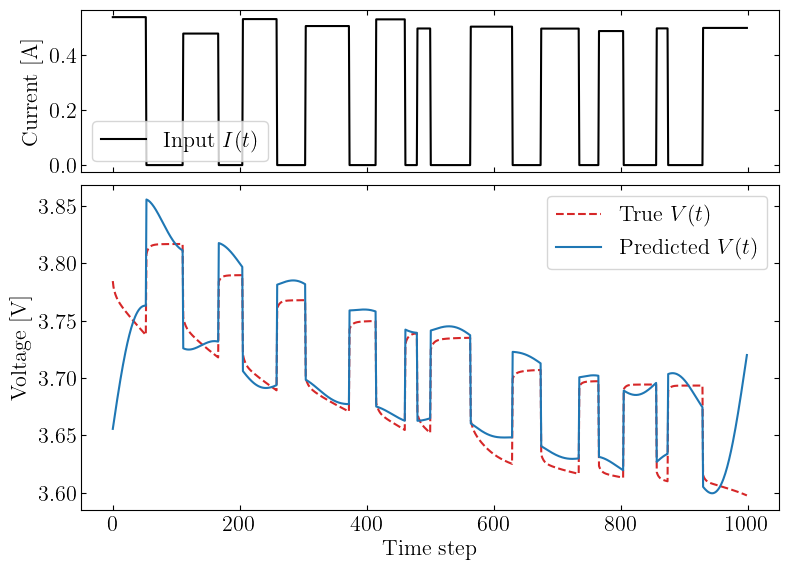

In [21]:
test = 0
i = I_test[test,0,:].reshape(1, 1, 1000) 
v = V_test[test,0,:].reshape(1, 1, 1000)

#print(i.shape, v.shape)
y_pred = model(torch.tensor(i, dtype=torch.float32))
f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
f.subplots_adjust(hspace=0.05)

ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax[1].plot(y_pred[0,0,:].detach().numpy(), label='Predicted $V(t)$', color='tab:blue')
ax[1].legend()
ax[0].legend()
ax[1].set_xlabel('Time step')
ax[0].set_ylabel('Current [A]')
ax[1].set_ylabel('Voltage [V]')
#plt.savefig('figs_NO/FNO_pred.pdf', bbox_inches='tight')
plt.show()

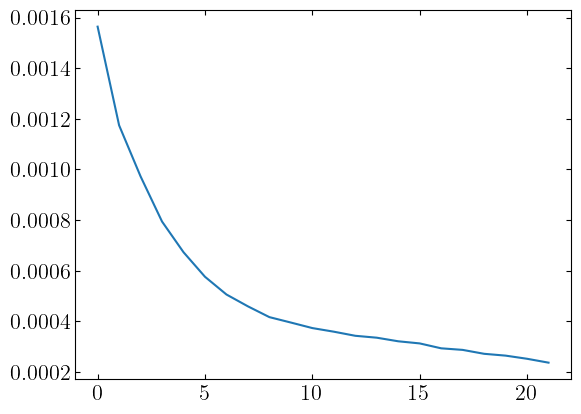

In [22]:
plt.plot(history['loss'])

In [18]:
T = 1000

u_test = np.zeros((1, 1,T))
y_test = np.zeros((1, 1,T))
w_test =  30# This is in the training range (0.5 to 2.0)

u_test[0,0,:] = np.sin(w_test * np.linspace(0, 3.14, T))  # w=1.5 is in the training range
y_test[0,0,:] = w_test * np.cos(w_test * np.linspace(0, 3.14, T))

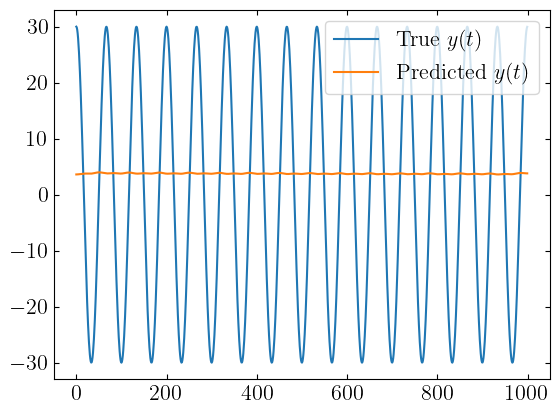

In [19]:
y_pred = model(torch.tensor(u_test, dtype=torch.float32))
plt.plot(y_test[0,0,:], label='True $y(t)$')
plt.plot(y_pred[0,0,:].detach().numpy(), label='Predicted $y(t)$')
plt.legend()
plt.show()